# House Price Prediction problem

Until now, we have completed the function fitting using Neural Nets, then binary and multi category classification. 

From fundamental, machine learning concepts, we have learnt what are 
1. optimizers
2. loss functions
3. backpropagations
4. train-test-validation datasets
5. how unseen data causes issues in model prediction
6. up sampling to reduce data bias

We shall now turn our attention towards:
1. Batching for training efficiency
2. Incorporate validation loss in the loop
3. Regularization and Dropout
4. feature normalization

This is a similar to "function-fitting" problem, we are given various factors like:
e.g., 
- $x_1 = \text{Square Footage}$
- $x_2 = \text{Number of Bedrooms}$
- $x_3 = \text{Age of House}$ 
- $x_4 = \text{Distance to City Center}$, 

based on which we have to predict the price of houses. 

First we have to create a training dataset:

In [22]:
# library imports
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
# set the random seed
np.random.seed(42)

# number of data points
n = 1000

# 1. Design features: torch.rand will generate numbers between 0 to 1
# 1.1 Consider minimum square footage to be 600 sqft
sqft = torch.rand(n, 1) * 3000 + 600 

# 2. Number of bedrooms: consider homes with 1 - 4 bedrooms
# 2.1 Create n samples, with n*1 shape
nbeds = torch.randint(1, 4, (n, 1)).float()

# 3. Age of house
# 3.1 Consider just built house, to max 30 years old
age = torch.randint(0, 30, (n, 1)).float()

# 4. Distance from city center (0 to 30 miles)
distance = torch.rand(n, 1)*30 

# 5. random noise
noise = torch.rand(n, 1)*20000

# 5. Compute a formula for the price
# 5.1 high sqft -> high price
# 5.2 more bedrooms -> higher price
# 5.3 older -> lesser price
# 5.4 farther -> lesser price
# also add random noise
price = (sqft * 150 + nbeds * 50000 - age * 2000 - distance * 3000 
         + noise)

## Feature Normalization

Due to distinctly different orders of magnitude of the features, if we don't normalize them, then the output price result will dominated by the sqft feature vector. Why? Becuase it has the highest magnitude. 

Try commenting out the feature normalization section and then training the network, you will see the difference in the predictions.

In [ ]:
# 6. Create the feature vector
x = torch.cat([sqft, nbeds, age, distance], dim=1)
y = price

# 6.1 check the sizes
assert x.size() == torch.Size([1000, 4])
assert y.size() == torch.Size([1000, 1])

# 6.2 compile the dataset
dataset = torch.utils.data.TensorDataset(x, y)

# 7. Do train, test validation split
train_set, test_set, val_set = torch.utils.data.random_split(
    dataset, [600, 200, 200], generator=torch.Generator().manual_seed(42)
)

# 7.1 split the train, test and val datasets in features and label vector
x_train, y_train = train_set[:][0], train_set[:][1]
x_test, y_test = test_set[:][0], test_set[:][1]
x_val, y_val = val_set[:][0], val_set[:][1]

# 7.1 Enable Batching
train_dataset = torch.utils.data.TensorDataset(x_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# 7.3 Feature normalization: use (feature - mean)/std
def featNorm(feature):
    return (feature - feature.mean(dim=0, keepdim=True))/feature.std(dim=0, keepdim=True)

# store general data mean and std for later use:
datamean, datastd = y_train.mean(dim=0, keepdim=True), y_train.std(dim=0, keepdim=True) 

x_train, y_train = featNorm(x_train), featNorm(y_train)
x_test, y_test = featNorm(x_test), featNorm(y_test)
x_val, y_val = featNorm(x_val), featNorm(y_val)


## Why `optimizer.zero_grad()`?

PyTorch accumulates gradients by default — every .backward() adds to the existing .grad values instead of replacing them.

So without optimizer.zero_grad():

- Epoch 1 computes gradients → updates weights
- Epoch 2 computes new gradients → adds them to the leftover ones from epoch 1
- The optimizer then steps with the wrong (inflated) gradient

# Batching

Until now, we used to give all the data to the training loop all at once. Lets say we had 600 training samples, the training loop, did the same mechanism on all of them before updating the weights:

1. Do forward pass on each of the 600 samples
2. Compute loss for each
3. Take average of the loss value

Once all 600 are done
4. Do backward pass, compute gradients
5. Update weights only once. 

This is called the Full Batch gradient. However here, the trainer has to store a lot of data in the GPU memory, which for small datasets might not matter much, but for large datasets matters a lot. 

Batching essentially divides the whole data into mini batches of 32/64 each (whatever number you give), and then does the above operation (weight update), once after every batch. In that way, we don't clog GPU memory as well as add some synthetic noise to the training dataset to make sure the network robustly learns learns features and helps escape local minima.

# Regularization and Dropout

- Dropout(0.2) only activates during training (model.train()); it disables automatically during inference (torch.no_grad() or model.eval()).
- weight_decay adds $\lambda \|\theta\|^2$   to the loss, pushing weights toward zero.

## Weight decay (low parameters):

If weights are huge, the model becomes overly sensitive — a tiny change in input (e.g., sqft +1) causes a massive price jump. Small weights mean smoother, gentler curves. The model learns broad trends instead of memorizing noise. It's like forcing the network to say "price depends a little on everything" rather than "price depends ONLY on sqft with a huge multiplier."

## Amazing insights on Dropout

During training, dropout randomly "knocks out" 20% of neurons in a layer. So the network can't rely on any single neuron being present. It forces every neuron to learn something useful independently, rather than co-adapting ("I'll handle sqft, you handle bedrooms"). At inference, all neurons are present but their outputs are scaled down — it's like averaging predictions from many smaller networks, which reduces overfitting.

### What does it mean by knock out?
Dropout affects only the layer it's placed after — not automatically all layers.

In your network:

`Linear(4, 4) → ReLU → Dropout(0.2) → Linear(4, 1)`

the Dropout(0.2) knocks out 20% of the 4 neurons coming out of that ReLU (the first hidden layer). It does not touch:

The input layer (4 features)
The output layer (1 neuron)

If you wanted dropout on another layer, you'd add another Dropout(0.2) after that layer's ReLU. It's common to put it after hidden layers, rarely after input or output.

### What if 20% of 4 Neurons is 0.8? how to drop 0.8 neurons? Or round it?

t's not a fixed count — it's probabilistic per neuron.

With 4 neurons and p=0.2, each neuron independently has a 20% chance of being dropped on that forward pass. So in one batch you might drop:

0 neurons
1 neuron (~32% chance)
2 neurons (~15% chance)
etc.
The expected number is 0.8, but the actual number varies randomly every time. PyTorch doesn't round — it flips a coin for each neuron. Over many batches, it averages out to ~20% being dropped.

### What if all neurons drop out?
t's possible but extremely unlikely: $(0.2)^4 = 0.0016$ (0.16% chance per forward pass).

If it happens:

- That layer outputs all zeros.
- The next layer (Linear(4, 1)) receives all zeros → predicts 0 (or bias only).
- The network learns to handle this because dropout trains it to work with missing neurons. Over many batches, it averages out.

In practice, with only 4 neurons, p=0.2 is aggressive. Most practitioners use dropout on larger layers (e.g., 64+ neurons) where losing all is astronomically unlikely. For your small network, it works but occasionally produces a "dead" batch — the gradient still flows through the surviving paths in other batches, so training recovers.

In [28]:
# 8. Design the network
"""
4 layers: 
Input layer contains 4 neurons: to take in 4 feature vectors
2 hidden layers of 4 and 2 neurons each
output layer contains 1 neurons: to give price outputs

Activated with ReLU() units
"""

housePricePredictor = torch.nn.Sequential(
    torch.nn.Linear(4, 4),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(4, 1)
)

# 8.1 Design the optimizer and the loss function
# Since this is a regression problem, Mean Squared Error loss should work good enough
optimizer = torch.optim.SGD(housePricePredictor.parameters(), 
                            lr=0.05,
                            weight_decay=0.01)
criterion = torch.nn.MSELoss()

# 9. Train the network now:
n_epochs = 1000

#9.1 create variables to store training history
training_loss, val_loss = [], []

for i in range(n_epochs):

    # make sure batching is take care of:
    for xb, yb in train_loader:

        # zero the gradients, to ensure no accumulated gradients
        optimizer.zero_grad()

        # pass the sample through the network
        predPrice = housePricePredictor(x_train)

        # compute loss function
        loss = criterion(predPrice, y_train)

        # compute gradients
        loss.backward()

        # update weights
        optimizer.step()


    # store training loss only after the batch
    training_loss.append(loss.item())

    # compute validation loss:
    with torch.no_grad():
        valPredPrice = housePricePredictor(x_val)
        val_loss.append(criterion(valPredPrice, y_val).item())

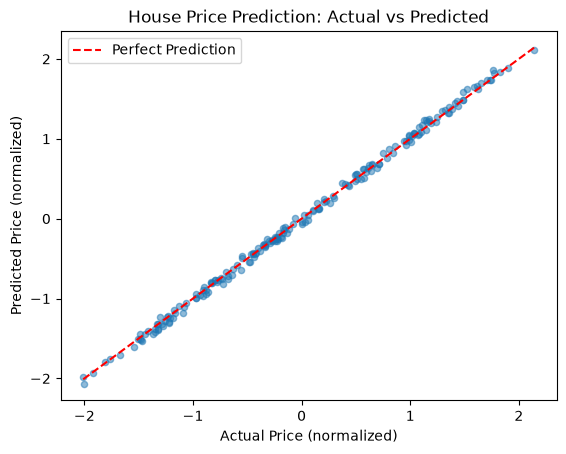

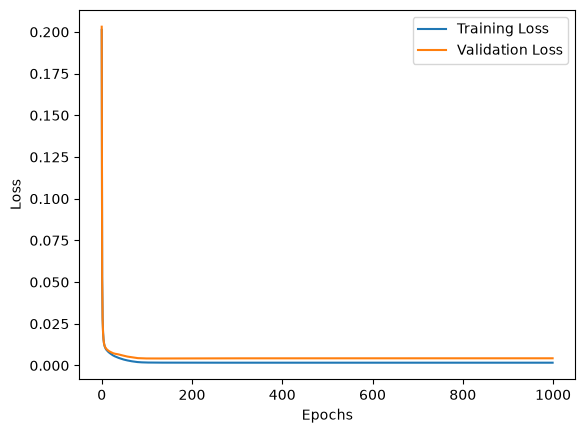

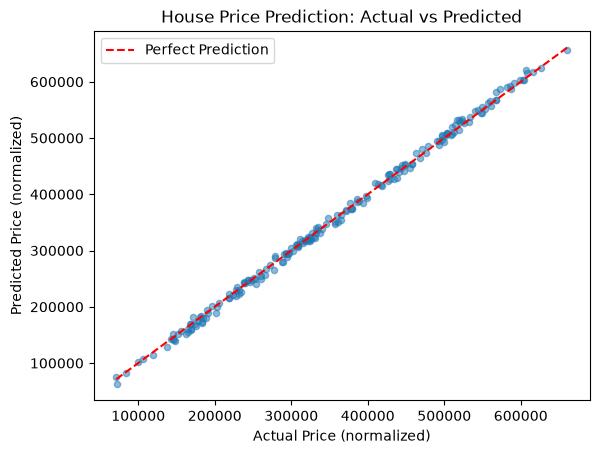

In [26]:
# 9 Inference
with torch.no_grad():
    y_pred = housePricePredictor(x_test)

# 10 plotting 
plt.scatter(y_test.numpy(), y_pred.numpy(), alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Price (normalized)")
plt.ylabel("Predicted Price (normalized)")
plt.title("House Price Prediction: Actual vs Predicted")
plt.legend()
plt.show()

# plot training and validation loss
plt.plot(training_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 11. lets denormalize and then plot again:
y_pred_real = y_pred * datastd + datamean
y_test_real = y_test * datastd + datamean
plt.scatter(y_test_real.numpy(), y_pred_real.numpy(), alpha=0.5, s=20)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Price (normalized)")
plt.ylabel("Predicted Price (normalized)")
plt.title("House Price Prediction: Actual vs Predicted")
plt.legend()
plt.show()